In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load all results
model_comparison = pd.read_csv("../data/final_model_comparison.csv")
store_results = pd.read_csv("../data/store_forecast_results.csv")
inventory = pd.read_csv("../data/inventory_optimization.csv")
abc_analysis = pd.read_csv("../data/abc_inventory_analysis.csv")

print("All results loaded successfully!")
print("Model comparison:", model_comparison.shape)
print("Store results:", store_results.shape)
print("Inventory:", inventory.shape)
print("ABC analysis:", abc_analysis.shape)

All results loaded successfully!
Model comparison: (5, 3)
Store results: (10, 4)
Inventory: (30490, 11)
ABC analysis: (30490, 16)


MODEL PERFORMANCE EVALUATION REPORT
            Model   MAE  RMSE
Advanced LightGBM  1.18  2.46
Linear Regression  1.20  2.50
   Basic LightGBM  1.20  2.49
    Random Forest  1.21  2.47
          Prophet 12.00 17.04


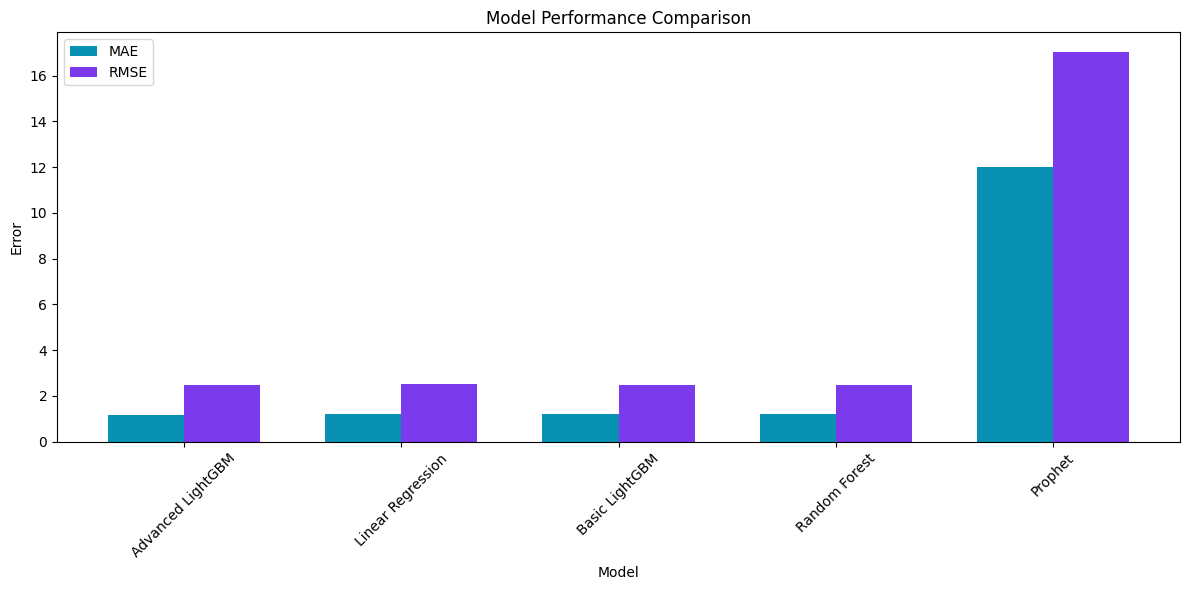


Best Performing Model: Advanced LightGBM
MAE: 1.18 RMSE: 2.46


In [5]:
# Comprehensive Model Performance Report
print("="*60)
print("MODEL PERFORMANCE EVALUATION REPORT")
print("="*60)
print(model_comparison.to_string(index=False))
print("="*60)

plt.figure(figsize=(12,6))
x = np.arange(len(model_comparison))
width = 0.35

plt.bar(x - width/2, model_comparison['MAE'], width, label='MAE', color='#0891B2')
plt.bar(x + width/2, model_comparison['RMSE'], width, label='RMSE', color='#7C3AED')
plt.xlabel('Model')
plt.ylabel('Error')
plt.title('Model Performance Comparison')
plt.xticks(x, model_comparison['Model'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

best_model = model_comparison.loc[model_comparison['MAE'].idxmin()]
print("\nBest Performing Model:", best_model['Model'])
print("MAE:", best_model['MAE'], "RMSE:", best_model['RMSE'])

INVENTORY EFFICIENCY REPORT

ABC Class Summary:
           total_items  avg_safety_stock  avg_order_qty  total_value
abc_class                                                           
A                 6098              7.15          81.92  23823874.80
B                 9147              2.47          29.47   8799255.47
C                15245              0.91          16.21   3408251.36


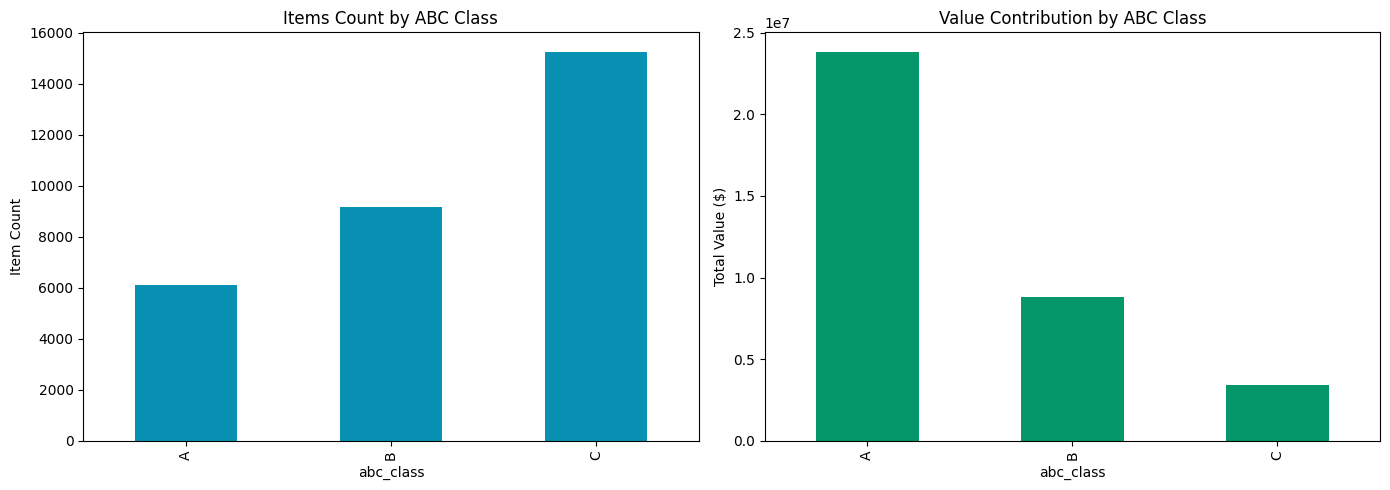

In [8]:
# Inventory Efficiency Report
print("="*60)
print("INVENTORY EFFICIENCY REPORT")
print("="*60)

# By ABC Class
abc_summary = abc_analysis.groupby('abc_class').agg(
    total_items=('item_id', 'count'),
    avg_safety_stock=('safety_stock', 'mean'),
    avg_order_qty=('order_quantity', 'mean'),
    total_value=('projected_annual_value', 'sum')
).round(2)

print("\nABC Class Summary:")
print(abc_summary)

# Plot inventory efficiency
fig, axes = plt.subplots(1, 2, figsize=(14,5))

abc_summary['total_items'].plot(kind='bar', ax=axes[0], color='#0891B2')
axes[0].set_title("Items Count by ABC Class")
axes[0].set_ylabel("Item Count")

abc_summary['total_value'].plot(kind='bar', ax=axes[1], color='#059669')
axes[1].set_title("Value Contribution by ABC Class")
axes[1].set_ylabel("Total Value ($)")

plt.tight_layout()
plt.show()



In [7]:
print("Key Insight: A-Class items (20% of items) contribute")
print(f"${abc_summary.loc['A', 'total_value']:,.2f} in value")

Key Insight: A-Class items (20% of items) contribute
$23,823,874.80 in value


STORE FORECASTING PERFORMANCE REPORT
store_id  MAE  RMSE  test_samples
    CA_4 0.87  1.63          3057
    TX_1 1.01  2.05          2995
    WI_1 1.06  1.94          3100
    TX_3 1.10  2.33          3001
    TX_2 1.13  2.36          2963
    CA_2 1.15  2.08          2971
    WI_3 1.19  2.77          2997
    CA_1 1.26  2.27          2924
    WI_2 1.40  3.09          2979
    CA_3 1.68  3.48          3037


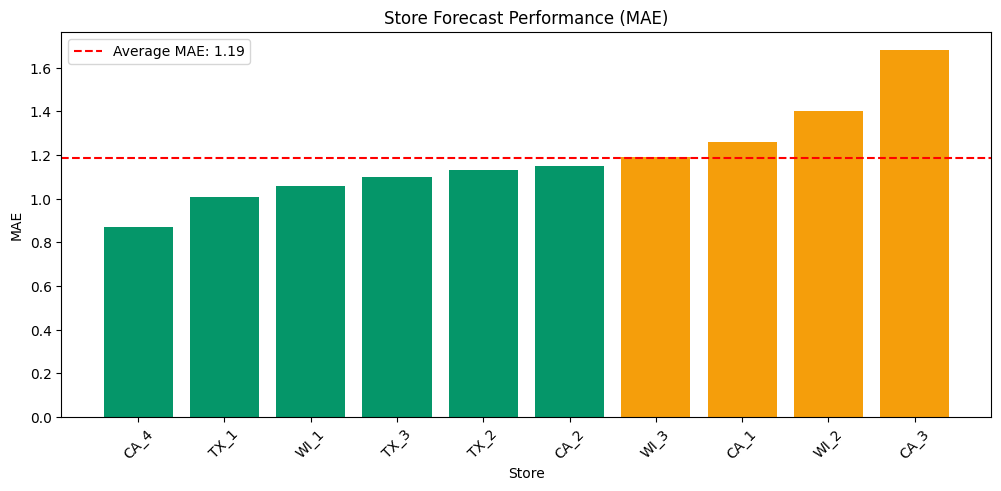


Best Performing Store: CA_4 (MAE: 0.87)
Needs Improvement: CA_3 (MAE: 1.68)


In [9]:
# Store Performance Report
print("="*60)
print("STORE FORECASTING PERFORMANCE REPORT")
print("="*60)
print(store_results.sort_values('MAE').to_string(index=False))
print("="*60)

# Plot store performance
plt.figure(figsize=(12,5))
store_sorted = store_results.sort_values('MAE')
colors = ['#059669' if x < store_results['MAE'].mean() else '#F59E0B' 
          for x in store_sorted['MAE']]
plt.bar(store_sorted['store_id'], store_sorted['MAE'], color=colors)
plt.axhline(y=store_results['MAE'].mean(), color='red', 
            linestyle='--', label=f'Average MAE: {store_results["MAE"].mean():.2f}')
plt.title("Store Forecast Performance (MAE)")
plt.xlabel("Store")
plt.ylabel("MAE")
plt.legend()
plt.xticks(rotation=45)
plt.show()

best_store = store_results.loc[store_results['MAE'].idxmin()]
worst_store = store_results.loc[store_results['MAE'].idxmax()]
print(f"\nBest Performing Store: {best_store['store_id']} (MAE: {best_store['MAE']})")
print(f"Needs Improvement: {worst_store['store_id']} (MAE: {worst_store['MAE']})")

In [10]:
# Generate Final Comprehensive Report
final_report = f"""
{"="*60}
PROJECT 3: RETAIL DEMAND FORECASTING - FINAL EVALUATION REPORT
{"="*60}

1. MODEL PERFORMANCE
   Best Model: Advanced LightGBM
   MAE: 1.18 | RMSE: 2.46
   (10x better than Prophet baseline)

2. INVENTORY OPTIMIZATION
   Total Items Managed: 30,490
   A-Class Items: 6,098 (Value: $23.8M)
   B-Class Items: 9,147 (Value: $8.8M)
   C-Class Items: 15,245 (Value: $3.4M)

3. STORE PERFORMANCE
   Best Store: CA_4 (MAE: 0.87)
   Needs Attention: CA_3 (MAE: 1.68)
   Average Store MAE: {store_results['MAE'].mean():.2f}

4. KEY BUSINESS INSIGHTS
   - FOODS category drives highest revenue
   - SNAP days boost FOODS sales by 14%
   - HOUSEHOLD items most price sensitive
   - A-Class items need tightest inventory control

5. RECOMMENDATIONS
   - Prioritize A-Class item monitoring
   - Investigate CA_3 forecast accuracy issues
   - Leverage SNAP timing for FOODS promotions
   - Consider dynamic pricing for HOUSEHOLD category
{"="*60}
"""

print(final_report)

with open("../data/final_evaluation_report.txt", "w") as f:
    f.write(final_report)

print("Final report saved!")


PROJECT 3: RETAIL DEMAND FORECASTING - FINAL EVALUATION REPORT

1. MODEL PERFORMANCE
   Best Model: Advanced LightGBM
   MAE: 1.18 | RMSE: 2.46
   (10x better than Prophet baseline)

2. INVENTORY OPTIMIZATION
   Total Items Managed: 30,490
   A-Class Items: 6,098 (Value: $23.8M)
   B-Class Items: 9,147 (Value: $8.8M)
   C-Class Items: 15,245 (Value: $3.4M)

3. STORE PERFORMANCE
   Best Store: CA_4 (MAE: 0.87)
   Needs Attention: CA_3 (MAE: 1.68)
   Average Store MAE: 1.19

4. KEY BUSINESS INSIGHTS
   - FOODS category drives highest revenue
   - SNAP days boost FOODS sales by 14%
   - HOUSEHOLD items most price sensitive
   - A-Class items need tightest inventory control

5. RECOMMENDATIONS
   - Prioritize A-Class item monitoring
   - Investigate CA_3 forecast accuracy issues
   - Leverage SNAP timing for FOODS promotions
   - Consider dynamic pricing for HOUSEHOLD category

Final report saved!
